# BCI IV-2a — Real EEG Alignment + FBCSP Diagnostic/Fix

This notebook is the next diagnostic stage after the preprocessing/FBCSP audit.

**Why this stage exists**

The current A01 results are:
- FBCSP+LDA ≈ 33.51%
- CRNN-only ≈ 41.49%

The important conclusion is that we should **not immediately tune the neural network**. First we must determine whether:
1. the T/E trial ordering and labels are aligned;
2. the real EEG contains class-discriminative MI information in a controlled within-subject experiment;
3. the FBCSP implementation behaves sensibly;
4. the LOSO drop is genuinely subject-shift rather than an extraction/label problem.

This notebook therefore adds:
- explicit T/E trial-alignment checks;
- A01 within-session classification sanity test;
- A01 T→E cross-session sanity test;
- class-wise PSD/ERD checks around C3/Cz/C4;
- two FBCSP variants for comparison:
  * normalized log-variance (current paper-style implementation)
  * log-variance without relative-power normalization;
- optional regularized CSP covariance;
- feature-count sweep before LASSO;
- a clean report for deciding whether the next problem is **data alignment**, **FBCSP**, or **CRNN**.

Do not enable full 9-subject training until this notebook passes the alignment sanity tests.


In [1]:
# ============================================================
# CELL 1 — IMPORTS / CONFIG
# ============================================================

import os, re, json, random, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.signal as signal
from scipy.linalg import eigh

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, balanced_accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import mne

warnings.filterwarnings("ignore")

SEED = 42
FS = 250
N_CHANNELS = 22
N_TIME = 1000
CLASS_NAMES = ["Left Hand", "Right Hand", "Feet", "Tongue"]
EVENT_TO_CLASS = {769: 0, 770: 1, 771: 2, 772: 3}
TRIAL_START_CODE = 768
EVAL_UNKNOWN_EVENT = 783

BANDS = [
    (1,4), (4,8), (8,12), (12,16), (16,20),
    (20,24), (24,28), (28,32), (32,35), (35,38)
]

CHANNEL_NAMES = [
    "Fz","FC3","FC1","FCz","FC2","FC4","C5","C3","C1","Cz","C2",
    "C4","C6","CP3","CP1","CPz","CP2","CP4","P3","P1","Pz","P2"
]

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

reset_seed(SEED)

DATA_ROOT_CANDIDATES = [
    Path.cwd() / "BCI IV-2a",
    Path.cwd() / "BCI_IV-2a",
    Path.cwd() / "BCI IV 2a",
    Path.cwd().parent / "BCI IV-2a",
    Path("/content/BCI IV-2a"),
]

def find_root():
    for p in DATA_ROOT_CANDIDATES:
        if p.exists() and (p / "A01T.gdf").exists():
            return p.resolve()
    for base in [Path.cwd(), Path.home()]:
        try:
            for p in base.rglob("A01T.gdf"):
                if p.parent.name.lower().replace("_"," ") in {"bci iv-2a","bci iv 2a"}:
                    return p.parent.resolve()
        except Exception:
            pass
    return None

DATA_ROOT = find_root()
print("DATA_ROOT:", DATA_ROOT)
if DATA_ROOT is None:
    raise FileNotFoundError("Set DATA_ROOT manually.")

TRUE_LABEL_ROOT = DATA_ROOT / "true_labels"


DATA_ROOT: /Users/ashokvarmabevara/MtechProj/BCI IV-2a


In [2]:
# ============================================================
# CELL 2 — GDF EVENT / LABEL UTILITIES
# ============================================================

def _parse_event_code(description):
    nums = re.findall(r"\d+", str(description))
    return int(nums[-1]) if nums else None

def _fill_continuous_nans(eeg):
    eeg = np.asarray(eeg, dtype=np.float32).copy()
    for ch in range(eeg.shape[0]):
        bad = ~np.isfinite(eeg[ch])
        if bad.any():
            good = eeg[ch][~bad]
            eeg[ch, bad] = float(np.mean(good)) if good.size else 0.0
    return eeg

def _bandpass_continuous(eeg, lo=1.0, hi=38.0, order=5):
    sos = signal.butter(order, [lo, hi], btype="bandpass", fs=FS, output="sos")
    return signal.sosfiltfilt(sos, eeg, axis=-1).astype(np.float32)

def read_gdf_continuous(path):
    raw = mne.io.read_raw_gdf(str(path), preload=True, verbose="ERROR")
    if not np.isclose(raw.info["sfreq"], FS):
        raise ValueError(f"{path}: expected {FS} Hz, got {raw.info['sfreq']}")
    data = raw.get_data()
    if data.shape[0] < N_CHANNELS:
        raise ValueError(f"{path}: only {data.shape[0]} channels")
    eeg = _fill_continuous_nans(data[:N_CHANNELS])
    eeg_1_38 = _bandpass_continuous(eeg)
    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    id_to_code = {eid: _parse_event_code(desc) for desc, eid in event_id.items()}
    parsed = []
    for sample, _, eid in events:
        code = id_to_code.get(eid)
        if code is not None:
            parsed.append((int(sample), int(code)))
    parsed.sort(key=lambda x: x[0])
    return raw, eeg_1_38, parsed

def get_trial_metadata(path, session_type):
    raw, eeg, parsed = read_gdf_continuous(path)
    selected_codes = set(EVENT_TO_CLASS) if session_type == "T" else {EVAL_UNKNOWN_EVENT}
    selected = [(s,c) for s,c in parsed if c in selected_codes]
    rows = []
    for idx, (cue, code) in enumerate(selected):
        starts = [s for s,c in parsed if c == TRIAL_START_CODE and s <= cue]
        start = starts[-1] if starts else np.nan
        rows.append({
            "trial_index": idx,
            "cue_sample": cue,
            "event_code": code,
            "trial_start_sample": start,
            "cue_delay_s": (cue-start)/FS if np.isfinite(start) else np.nan,
            "epoch_end": cue + N_TIME
        })
    return raw, eeg, pd.DataFrame(rows)

print("Utilities loaded.")


Utilities loaded.


In [3]:
# ============================================================
# CELL 3 — EXPLICIT A01 T/E ALIGNMENT AUDIT
# ============================================================

def audit_a01_events():
    outputs = {}
    for sess in ["T","E"]:
        p = DATA_ROOT / f"A01{sess}.gdf"
        raw, eeg, meta = get_trial_metadata(p, sess)
        outputs[sess] = {"raw": raw, "eeg": eeg, "meta": meta}
        print(f"\nA01{sess}.gdf")
        print("continuous EEG shape:", eeg.shape)
        print("trials:", len(meta))
        print("event codes:", meta["event_code"].value_counts().sort_index().to_dict())
        print(
            "cue delay statistics:",
            meta["cue_delay_s"].describe().round(4).to_dict()
            if meta["cue_delay_s"].notna().any() else "N/A"
        )
        bad = meta[
            (meta["epoch_end"] > eeg.shape[1]) |
            (meta["cue_delay_s"].notna() & ((meta["cue_delay_s"] < 1.5) | (meta["cue_delay_s"] > 2.5)))
        ]
        print("timing/epoch anomalies:", len(bad))
        display(meta.head(10))
    assert len(outputs["T"]["meta"]) == 288, "A01T should contain 288 cue trials."
    assert len(outputs["E"]["meta"]) == 288, "A01E should contain 288 cue trials."
    return outputs

A01_EVENTS = audit_a01_events()



A01T.gdf
continuous EEG shape: (22, 672528)
trials: 288
event codes: {769: 72, 770: 72, 771: 72, 772: 72}
cue delay statistics: {'count': 288.0, 'mean': 2.0, 'std': 0.0, 'min': 2.0, '25%': 2.0, '50%': 2.0, '75%': 2.0, 'max': 2.0}
timing/epoch anomalies: 0


,trial_index,cue_sample,event_code,trial_start_sample,cue_delay_s,epoch_end
0,0,92368,772,91868,2.0,93368
1,1,94371,771,93871,2.0,95371
2,2,96289,770,95789,2.0,97289
3,3,98241,769,97741,2.0,99241
4,4,100249,769,99749,2.0,101249
5,5,102360,770,101860,2.0,103360
6,6,104277,771,103777,2.0,105277
7,7,106327,772,105827,2.0,107327
8,8,108258,770,107758,2.0,109258
9,9,110256,771,109756,2.0,111256



A01E.gdf
continuous EEG shape: (22, 687000)
trials: 288
event codes: {783: 288}
cue delay statistics: {'count': 288.0, 'mean': 2.0, 'std': 0.0, 'min': 2.0, '25%': 2.0, '50%': 2.0, '75%': 2.0, 'max': 2.0}
timing/epoch anomalies: 0


,trial_index,cue_sample,event_code,trial_start_sample,cue_delay_s,epoch_end
0,0,106840,783,106340,2.0,107840
1,1,108843,783,108343,2.0,109843
2,2,110761,783,110261,2.0,111761
3,3,112713,783,112213,2.0,113713
4,4,114721,783,114221,2.0,115721
5,5,116832,783,116332,2.0,117832
6,6,118749,783,118249,2.0,119749
7,7,120799,783,120299,2.0,121799
8,8,122730,783,122230,2.0,123730
9,9,124728,783,124228,2.0,125728


In [4]:
# ============================================================
# CELL 4 — TRUE E-LABEL LOADER + ORDER CHECK
# ============================================================

import scipy.io as sio

def _flatten_numeric_arrays(obj):
    out=[]
    if isinstance(obj, np.ndarray):
        if np.issubdtype(obj.dtype, np.number):
            out.append(obj.ravel())
        elif obj.dtype == object:
            for v in obj.ravel():
                out.extend(_flatten_numeric_arrays(v))
    elif isinstance(obj, dict):
        for v in obj.values():
            out.extend(_flatten_numeric_arrays(v))
    elif isinstance(obj, (list,tuple)):
        for v in obj:
            out.extend(_flatten_numeric_arrays(v))
    return out

def candidate_label_files(subject_id):
    if not TRUE_LABEL_ROOT.exists():
        return []
    out=[]
    for p in TRUE_LABEL_ROOT.rglob("*"):
        if p.is_file() and subject_id.lower() in str(p).lower() and p.suffix.lower() in {".mat",".txt",".csv",".tsv",".npy"}:
            out.append(p)
    return sorted(out)

def load_true_labels(subject_id, n=288):
    files = candidate_label_files(subject_id)
    errors=[]
    for p in files:
        try:
            if p.suffix.lower() == ".mat":
                mat = sio.loadmat(p, squeeze_me=True, struct_as_record=False)
                arrays = _flatten_numeric_arrays(mat)
                cand = []
                for a in arrays:
                    a=np.asarray(a).ravel()
                    if len(a)>=n:
                        vals=set(np.unique(a).tolist())
                        if vals.issubset({0,1,2,3}) and len(vals)==4:
                            cand.append(a.astype(int))
                        elif vals.issubset({1,2,3,4}) and len(vals)==4:
                            cand.append((a-1).astype(int))
                if not cand:
                    raise ValueError("no 4-class vector")
                cand.sort(key=len, reverse=True)
                y=cand[0]
            elif p.suffix.lower()==".npy":
                y=np.asarray(np.load(p)).ravel()
            else:
                y=np.asarray(np.loadtxt(p, delimiter="," if p.suffix.lower()==".csv" else None)).ravel()
            vals=set(np.unique(y).astype(int).tolist())
            if vals.issubset({1,2,3,4}):
                y=y.astype(int)-1
            else:
                y=y.astype(int)
            if len(y)==n and set(np.unique(y).tolist())=={0,1,2,3}:
                print(f"{subject_id} labels: {p.name}")
                return y
        except Exception as e:
            errors.append((str(p), str(e)))
    raise RuntimeError(f"No valid {n}-label vector for {subject_id}: {errors}")

A01_E_LABELS = load_true_labels("A01", 288)
print("A01E labels:", A01_E_LABELS.shape, np.bincount(A01_E_LABELS))


A01 labels: A01E.mat
A01E labels: (288,) [72 72 72 72]


In [5]:
# ============================================================
# CELL 5 — MATERIALIZE A01 22×1000 EPOCHS DIRECTLY FROM CONTINUOUS DATA
# ============================================================

def epoch_from_continuous(eeg, meta):
    X=[]
    for s in meta["cue_sample"].astype(int):
        block=eeg[:, s:s+N_TIME]
        if block.shape == (N_CHANNELS,N_TIME):
            X.append(block)
    X=np.asarray(X,dtype=np.float32)
    return X

A01_XT = epoch_from_continuous(A01_EVENTS["T"]["eeg"], A01_EVENTS["T"]["meta"])
A01_XE = epoch_from_continuous(A01_EVENTS["E"]["eeg"], A01_EVENTS["E"]["meta"])
A01_yT = np.array([EVENT_TO_CLASS[c] for c in A01_EVENTS["T"]["meta"]["event_code"]], dtype=int)
A01_yE = A01_E_LABELS.copy()

print("A01T:", A01_XT.shape, "classes:", np.bincount(A01_yT))
print("A01E:", A01_XE.shape, "classes:", np.bincount(A01_yE))


A01T: (288, 22, 1000) classes: [72 72 72 72]
A01E: (288, 22, 1000) classes: [72 72 72 72]


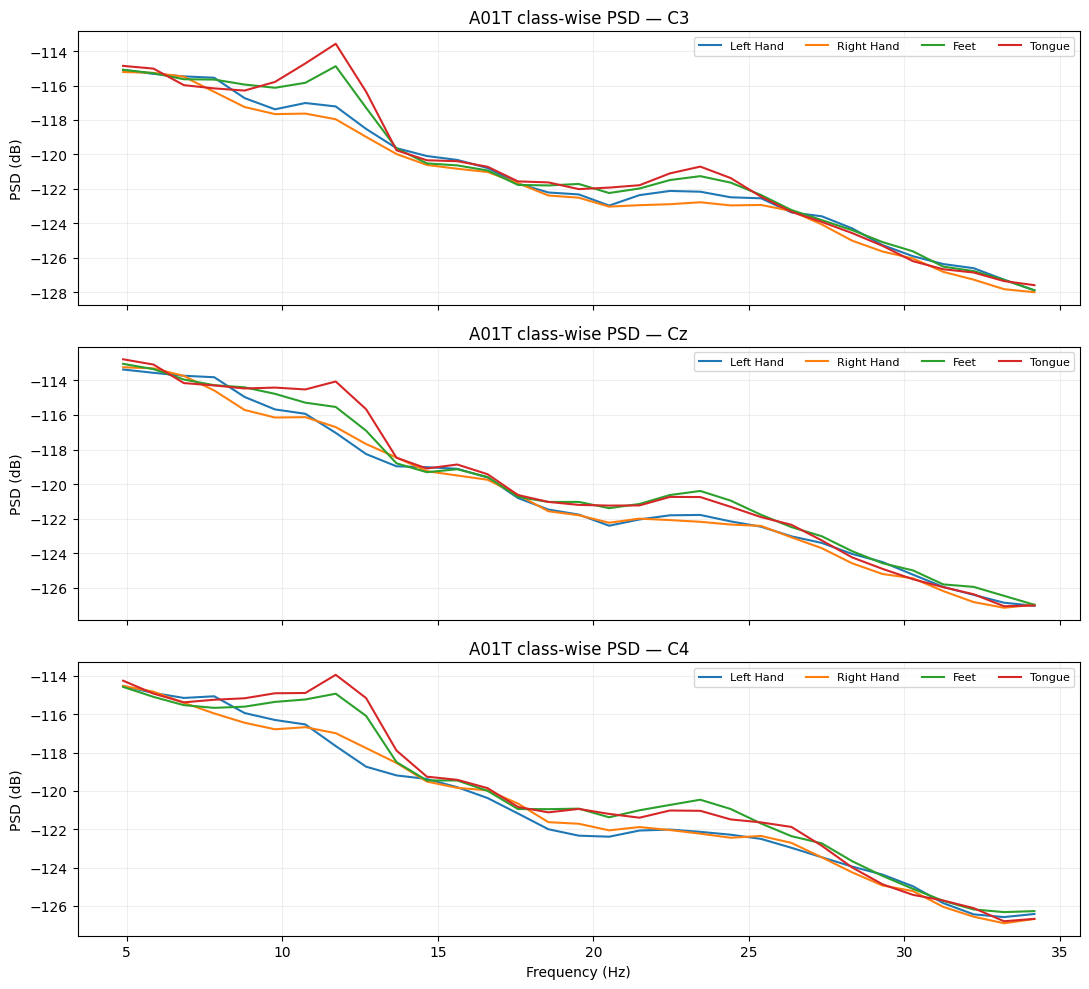

In [6]:

# ============================================================
# CELL — FIXED C3 / CZ / C4 CLASS-WISE PSD AUDIT
# ============================================================

MI_CH = {
    "C3": 7,
    "Cz": 9,
    "C4": 11,
}


def welch_class_psd(X, y, ch, fs=FS):
    rows = []

    for class_id, class_name in enumerate(CLASS_NAMES):

        xc = X[y == class_id, ch, :]

        if xc.shape[0] == 0:
            continue

        f, p = signal.welch(
            xc,
            fs=fs,
            nperseg=min(256, xc.shape[-1]),
            axis=-1
        )

        mask = (f >= 4.0) & (f <= 35.0)

        # IMPORTANT:
        # p has shape (trials, frequencies), so apply the
        # frequency mask on axis=1.
        p_selected = p[:, mask]

        p_mean = p_selected.mean(axis=0)

        rows.append(
            (class_name, f[mask], p_mean)
        )

    return rows


def plot_class_psd(X, y, title):

    fig, axes = plt.subplots(
        3, 1,
        figsize=(11, 10),
        sharex=True
    )

    for ax, (channel_name, channel_index) in zip(
        axes,
        MI_CH.items()
    ):

        rows = welch_class_psd(
            X,
            y,
            channel_index
        )

        for class_name, f, p in rows:

            ax.plot(
                f,
                10 * np.log10(p + 1e-15),
                linewidth=1.5,
                label=class_name
            )

        ax.set_title(
            f"{title} — {channel_name}"
        )
        ax.set_ylabel("PSD (dB)")
        ax.grid(alpha=0.2)
        ax.legend(
            ncol=4,
            fontsize=8
        )

    axes[-1].set_xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()


# RUN
plot_class_psd(
    A01_XT,
    A01_yT,
    "A01T class-wise PSD"
)


In [7]:
# ============================================================
# CELL 7 — CONTROLLED WITHIN-SUBJECT A01T SPLIT
# ============================================================

def evaluate_lda(Xtr, ytr, Xva, yva, name):
    lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    lda.fit(Xtr,ytr)
    pred=lda.predict(Xva)
    print(
        f"{name}: acc={accuracy_score(yva,pred)*100:.2f}% | "
        f"balanced={balanced_accuracy_score(yva,pred)*100:.2f}% | "
        f"kappa={cohen_kappa_score(yva,pred):.4f}"
    )
    return lda,pred

print("Within-subject check will use A01T only.")
idx_tr, idx_va = train_test_split(
    np.arange(len(A01_XT)),
    test_size=0.25,
    random_state=SEED,
    stratify=A01_yT
)
print("A01T split:", len(idx_tr), "train /", len(idx_va), "validation")


Within-subject check will use A01T only.
A01T split: 216 train / 72 validation


In [8]:
# ============================================================
# CELL 8 — FBCSP IMPLEMENTATION WITH TWO FEATURE DEFINITIONS
# ============================================================

class FBCSPDiagnostic:
    def __init__(self, m=4, regularization=0.0):
        self.m=m
        self.regularization=regularization
        self.W=[]
        self.meta=[]

    @staticmethod
    def cov_norm(x):
        c=x @ x.T
        tr=np.trace(c)
        return c/(tr+1e-12)

    def fit(self, Xfb, y):
        self.W=[]; self.meta=[]
        gi=0
        for b,(lo,hi) in enumerate(BANDS):
            Xb=Xfb[:,b]
            filters=[]
            for c in range(4):
                Rc=np.mean([self.cov_norm(x) for x in Xb[y==c]],axis=0)
                Rr=np.mean([self.cov_norm(x) for x in Xb[y!=c]],axis=0)
                if self.regularization>0:
                    I=np.eye(N_CHANNELS)
                    Rc=(1-self.regularization)*Rc+self.regularization*I/N_CHANNELS
                    Rr=(1-self.regularization)*Rr+self.regularization*I/N_CHANNELS
                vals, vecs=eigh(Rc+1e-10*np.eye(N_CHANNELS), Rr+1e-10*np.eye(N_CHANNELS))
                order=np.argsort(vals)[::-1]
                vals=vals[order]; vecs=vecs[:,order]
                W=vecs[:,:self.m]
                filters.append(W)
                for r in range(self.m):
                    self.meta.append({
                        "global_index":gi, "band":f"{lo}-{hi} Hz",
                        "band_index":b, "ovr_class":CLASS_NAMES[c],
                        "csp_rank":r+1, "eigenvalue":float(vals[r])
                    })
                    gi+=1
            self.W.append(np.hstack(filters))
        return self

    def _features_band(self, Xb, W, relative=True):
        Z=np.einsum("cf,nct->nft", W, Xb)
        v=np.var(Z,axis=-1)
        if relative:
            v=v/(np.sum(v,axis=1,keepdims=True)+1e-12)
        return np.log(v+1e-12)

    def transform(self, Xfb, relative=True):
        out=[]
        for b in range(len(BANDS)):
            out.append(self._features_band(Xfb[:,b], self.W[b], relative))
        return np.concatenate(out,axis=1)

def build_filter_bank(X, order=5):
    out=[]
    for lo,hi in BANDS:
        sos=signal.butter(order,[lo,hi],btype="bandpass",fs=FS,output="sos")
        out.append(signal.sosfiltfilt(sos,X,axis=-1).astype(np.float32))
    return np.stack(out,axis=1)


In [9]:
# ============================================================
# CELL 9 — TRAINING-ONLY NORMALIZATION + WITHIN-SUBJECT FBCSP
# ============================================================

def fit_norm(X):
    mu=X.mean(axis=(0,2),keepdims=True)
    sd=X.std(axis=(0,2),keepdims=True)+1e-6
    return mu.astype(np.float32),sd.astype(np.float32)

def norm(X,mu,sd):
    return ((X-mu)/sd).astype(np.float32)

# A01T-only fit for within-subject split
mu_t,sd_t=fit_norm(A01_XT[idx_tr])
Xtr_n=norm(A01_XT[idx_tr],mu_t,sd_t)
Xva_n=norm(A01_XT[idx_va],mu_t,sd_t)

print("within-subject z-score:")
print("max abs train mean:", float(np.max(np.abs(Xtr_n.mean(axis=(0,2))))))
print("max abs train std-1:", float(np.max(np.abs(Xtr_n.std(axis=(0,2))-1))))

Xtr_fb=build_filter_bank(Xtr_n)
Xva_fb=build_filter_bank(Xva_n)

fbcsp=FBCSPDiagnostic(m=4,regularization=0.0).fit(Xtr_fb,A01_yT[idx_tr])

Ftr_rel=fbcsp.transform(Xtr_fb,relative=True)
Fva_rel=fbcsp.transform(Xva_fb,relative=True)

Ftr_abs=fbcsp.transform(Xtr_fb,relative=False)
Fva_abs=fbcsp.transform(Xva_fb,relative=False)

print("candidate feature shape:", Ftr_rel.shape)

print("\nWITHIN-SUBJECT FBCSP+LDA — relative log-variance")
lda_rel,p_rel=evaluate_lda(Ftr_rel,A01_yT[idx_tr],Fva_rel,A01_yT[idx_va],"A01T split / relative")

print("\nWITHIN-SUBJECT FBCSP+LDA — absolute log-variance")
lda_abs,p_abs=evaluate_lda(Ftr_abs,A01_yT[idx_tr],Fva_abs,A01_yT[idx_va],"A01T split / absolute")


within-subject z-score:
max abs train mean: 1.7492858717105264e-08
max abs train std-1: 0.1296578049659729
candidate feature shape: (216, 160)

WITHIN-SUBJECT FBCSP+LDA — relative log-variance
A01T split / relative: acc=75.00% | balanced=75.00% | kappa=0.6667

WITHIN-SUBJECT FBCSP+LDA — absolute log-variance
A01T split / absolute: acc=76.39% | balanced=76.39% | kappa=0.6852


A01T -> A01E FBCSP+LDA
A01T → A01E: acc=75.69% | balanced=75.69% | kappa=0.6759


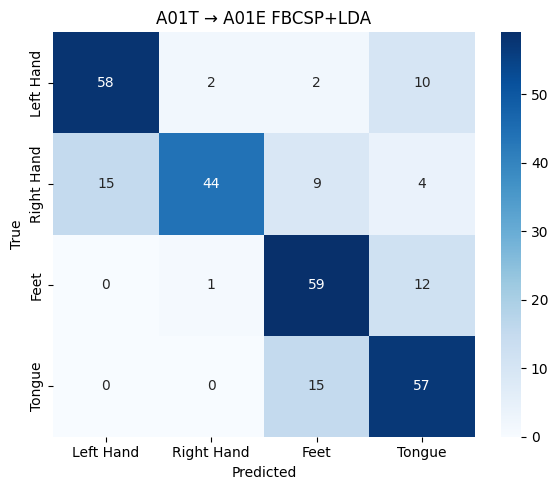

In [10]:
# ============================================================
# CELL 10 — CROSS-SESSION A01T → A01E CHECK
# ============================================================

# Fit normalization ONLY on A01T.
mu_cross, sd_cross = fit_norm(A01_XT)
XTn = norm(A01_XT,mu_cross,sd_cross)
XEn = norm(A01_XE,mu_cross,sd_cross)

XTfb=build_filter_bank(XTn)
XEfb=build_filter_bank(XEn)

cross_fbcsp=FBCSPDiagnostic(m=4,regularization=0.0).fit(XTfb,A01_yT)
F_T=cross_fbcsp.transform(XTfb,relative=True)
F_E=cross_fbcsp.transform(XEfb,relative=True)

print("A01T -> A01E FBCSP+LDA")
lda_cross,p_cross=evaluate_lda(
    F_T,A01_yT,F_E,A01_yE,"A01T → A01E"
)

cm=confusion_matrix(A01_yE,p_cross,labels=np.arange(4))
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
plt.title("A01T → A01E FBCSP+LDA")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


LOADING ALL BCI IV-2a SUBJECTS
A01 labels: A01E.mat
A01: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A02 labels: A02E.mat
A02: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A03 labels: A03E.mat
A03: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A04 labels: A04E.mat
A04: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A05 labels: A05E.mat
A05: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A06 labels: A06E.mat
A06: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A07 labels: A07E.mat
A07: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A08 labels: A08E.mat
A08: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A09 labels: A09E.mat
A09: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s

STRICT LOSO CHECK
Train subjects : ['A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Test subject   : A01
Train shape    : (4608, 22,

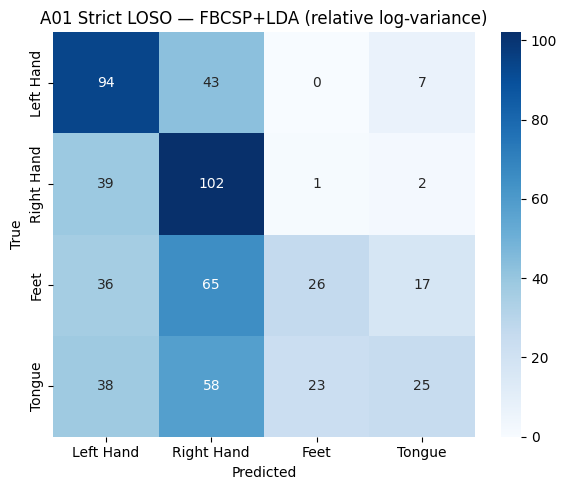


------------------------------------------------------------------------
A01 STRICT LOSO — FBCSP + LDA
absolute log-variance
------------------------------------------------------------------------
A02-A09 → A01: acc=40.97% | balanced=40.97% | kappa=0.2130


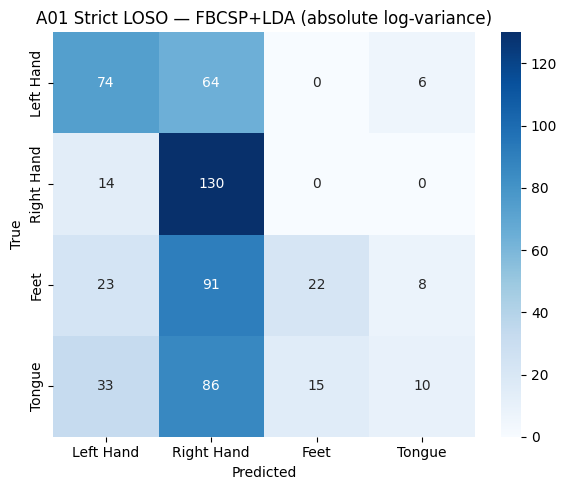


Cell 11 complete.


In [11]:
# ============================================================
# CELL 11 — STRICT LOSO A01 FBCSP DIAGNOSTIC (SELF-CONTAINED)
# ============================================================
# This replaces the previous Cell 11.
#
# The previous version expected a variable called `subjects`
# from another notebook. That variable does not exist in this
# standalone notebook, so the cell raised:
#
# RuntimeError: Run the original real-data loading notebook...
#
# This version loads A01-A09 directly from the GDF files using
# the utilities already defined in Cells 1-10.

def load_subject_2a(subject_id):
    """
    Load one BCI IV-2a subject:
      - T session: 288 trials, labels from GDF events 769-772
      - E session: 288 trials, labels from true_labels/*
    Returns:
      X: (576, 22, 1000)
      y: (576,)
      meta: trial/session metadata
    """
    # -------------------------
    # Training session
    # -------------------------
    t_path = DATA_ROOT / f"{subject_id}T.gdf"
    if not t_path.exists():
        raise FileNotFoundError(f"Missing {t_path}")

    _, eeg_T, meta_T = get_trial_metadata(t_path, "T")
    X_T = epoch_from_continuous(eeg_T, meta_T)

    if len(meta_T) != 288 or X_T.shape != (288, N_CHANNELS, N_TIME):
        raise ValueError(
            f"{subject_id}T unexpected shape/meta: "
            f"meta={len(meta_T)}, X={X_T.shape}"
        )

    y_T = np.array(
        [EVENT_TO_CLASS[int(c)] for c in meta_T["event_code"]],
        dtype=np.int64
    )

    # -------------------------
    # Evaluation session
    # -------------------------
    e_path = DATA_ROOT / f"{subject_id}E.gdf"
    if not e_path.exists():
        raise FileNotFoundError(f"Missing {e_path}")

    _, eeg_E, meta_E = get_trial_metadata(e_path, "E")
    X_E = epoch_from_continuous(eeg_E, meta_E)

    if len(meta_E) != 288 or X_E.shape != (288, N_CHANNELS, N_TIME):
        raise ValueError(
            f"{subject_id}E unexpected shape/meta: "
            f"meta={len(meta_E)}, X={X_E.shape}"
        )

    y_E = load_true_labels(subject_id, 288)

    # -------------------------
    # IMPORTANT: verify E order
    # -------------------------
    if len(y_E) != len(X_E):
        raise ValueError(
            f"{subject_id}E label count mismatch: "
            f"{len(y_E)} labels vs {len(X_E)} epochs"
        )

    X = np.concatenate([X_T, X_E], axis=0)
    y = np.concatenate([y_T, y_E], axis=0)

    meta = pd.concat([
        meta_T.assign(session="T"),
        meta_E.assign(session="E")
    ], ignore_index=True)

    return X.astype(np.float32), y.astype(np.int64), meta


def load_all_subjects_2a(subject_ids=None):
    if subject_ids is None:
        subject_ids = [f"A{i:02d}" for i in range(1, 10)]

    datasets = {}

    print("=" * 72)
    print("LOADING ALL BCI IV-2a SUBJECTS")
    print("=" * 72)

    for sid in subject_ids:
        t0 = time.time()

        X, y, meta = load_subject_2a(sid)

        datasets[sid] = {
            "X": X,
            "y": y,
            "meta": meta
        }

        counts = np.bincount(y, minlength=4)

        print(
            f"{sid}: X={X.shape} | "
            f"class_counts={counts.tolist()} | "
            f"time={time.time()-t0:.1f}s"
        )

        # Every subject should have 144 trials/class total.
        if not np.array_equal(counts, np.array([144, 144, 144, 144])):
            raise ValueError(
                f"{sid}: unexpected class counts {counts.tolist()}"
            )

    print("=" * 72)
    return datasets


# ------------------------------------------------------------
# LOAD THE DATASET DIRECTLY FROM THIS NOTEBOOK
# ------------------------------------------------------------

ALL_SUBJECTS = load_all_subjects_2a()

# ------------------------------------------------------------
# STRICT LOSO A01
# ------------------------------------------------------------

TEST_SUBJECT = "A01"
TRAIN_SUBJECTS = [
    sid for sid in ALL_SUBJECTS.keys()
    if sid != TEST_SUBJECT
]

X_loso = np.concatenate(
    [ALL_SUBJECTS[sid]["X"] for sid in TRAIN_SUBJECTS],
    axis=0
)

y_loso = np.concatenate(
    [ALL_SUBJECTS[sid]["y"] for sid in TRAIN_SUBJECTS],
    axis=0
)

X_test_loso = ALL_SUBJECTS[TEST_SUBJECT]["X"]
y_test_loso = ALL_SUBJECTS[TEST_SUBJECT]["y"]

print("\nSTRICT LOSO CHECK")
print("Train subjects :", TRAIN_SUBJECTS)
print("Test subject   :", TEST_SUBJECT)
print("Train shape    :", X_loso.shape)
print("Test shape     :", X_test_loso.shape)
print("Train classes  :", np.bincount(y_loso, minlength=4))
print("Test classes   :", np.bincount(y_test_loso, minlength=4))

# ------------------------------------------------------------
# TRAINING-ONLY NORMALIZATION
# ------------------------------------------------------------

mu_l, sd_l = fit_norm(X_loso)

Xln = norm(X_loso, mu_l, sd_l)
XTn = norm(X_test_loso, mu_l, sd_l)

print("\nNORMALIZATION CHECK")
print("max |train mean|:", float(np.max(np.abs(Xln.mean(axis=(0,2))))))
print(
    "max |train std-1|:",
    float(np.max(np.abs(Xln.std(axis=(0,2)) - 1)))
)

# ------------------------------------------------------------
# FILTER BANK
# ------------------------------------------------------------

print("\nBUILDING 10-BAND FILTER BANK...")
Xlfb = build_filter_bank(Xln)
XTfb = build_filter_bank(XTn)

print("filter-bank train:", Xlfb.shape)
print("filter-bank test :", XTfb.shape)

# ------------------------------------------------------------
# FBCSP FIT ONLY ON TRAINING SUBJECTS
# ------------------------------------------------------------

print("\nFITTING FBCSP ON A02-A09 ONLY...")

loso_fbcsp = FBCSPDiagnostic(
    m=4,
    regularization=0.0
).fit(Xlfb, y_loso)

print("FBCSP candidate dimensions:", len(loso_fbcsp.meta))

# ------------------------------------------------------------
# COMPARE TWO CSP FEATURE DEFINITIONS
# ------------------------------------------------------------

for relative in [True, False]:

    label = "relative log-variance" if relative else "absolute log-variance"

    F_l = loso_fbcsp.transform(
        Xlfb,
        relative=relative
    )

    F_t = loso_fbcsp.transform(
        XTfb,
        relative=relative
    )

    print("\n" + "-" * 72)
    print("A01 STRICT LOSO — FBCSP + LDA")
    print(label)
    print("-" * 72)

    lda_loso, pred_loso = evaluate_lda(
        F_l,
        y_loso,
        F_t,
        y_test_loso,
        "A02-A09 → A01"
    )

    cm = confusion_matrix(
        y_test_loso,
        pred_loso,
        labels=np.arange(4)
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f"A01 Strict LOSO — FBCSP+LDA ({label})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

print("\nCell 11 complete.")


### Note about the previous error

The earlier Cell 11 depended on a variable named `subjects` that was created in a different notebook. This notebook is now self-contained: it loads A01–A09 directly from the `.gdf` files and the `true_labels` folder before constructing the strict A01 LOSO fold.

The strict LOSO split remains:
- Training: A02–A09 = 4,608 trials
- Test: A01 = 576 trials


In [12]:
# ============================================================
# CELL 12 — DIAGNOSTIC DECISION GATE
# ============================================================

results = {
    "within_subject_A01T_relative": accuracy_score(A01_yT[idx_va], p_rel),
    "within_subject_A01T_absolute": accuracy_score(A01_yT[idx_va], p_abs),
    "cross_session_A01T_to_A01E": accuracy_score(A01_yE, p_cross),
}

print(pd.Series(results).mul(100).round(2).to_string())

print("\nINTERPRETATION GATE")
print("1. Within-subject >= ~50% and cross-session >= ~40%:")
print("   EEG/event extraction is likely usable; LOSO subject shift is the main difficulty.")
print("2. Within-subject ~25-35%:")
print("   Strong evidence of a preprocessing/FBCSP/event-alignment problem.")
print("3. Within-subject good but cross-session poor:")
print("   Session shift / normalization / label-order issue needs attention.")
print("4. Relative-vs-absolute variance changes performance substantially:")
print("   FBCSP feature definition is a meaningful source of the gap.")
print("\nDo NOT enable FBGAN yet.")


within_subject_A01T_relative    75.00
within_subject_A01T_absolute    76.39
cross_session_A01T_to_A01E      75.69

INTERPRETATION GATE
1. Within-subject >= ~50% and cross-session >= ~40%:
   EEG/event extraction is likely usable; LOSO subject shift is the main difficulty.
2. Within-subject ~25-35%:
   Strong evidence of a preprocessing/FBCSP/event-alignment problem.
3. Within-subject good but cross-session poor:
   Session shift / normalization / label-order issue needs attention.
4. Relative-vs-absolute variance changes performance substantially:
   FBCSP feature definition is a meaningful source of the gap.

Do NOT enable FBGAN yet.


## Expected next step

After these diagnostics, use the result to decide:

- **Data-alignment problem** → fix GDF/event/label extraction.
- **Within-subject good, LOSO poor** → keep preprocessing and focus on subject-invariant CRNN/domain adaptation.
- **Relative vs absolute FBCSP differs strongly** → use the paper-consistent feature definition consistently.
- **All classical checks are good but CRNN remains low** → inspect the exact CRNN-DF implementation and optimization.

The paper's reported values are still the final references:
- CRNN-DF: **63.52 ± 10.70%**
- CRNN-DF + 3,000 FBGAN samples: **72.82 ± 10.44%**

These numbers should be compared only after the evaluation protocol is fixed and the A01 test subject remains untouched during model selection.


# STAGE 1 — Paper-faithful CRNN baseline

The preprocessing/FBCSP diagnostics established:

- A01T within-subject FBCSP+LDA ≈ 75%
- A01T → A01E FBCSP+LDA ≈ 75.7%
- A02–A09 → A01 FBCSP+LDA ≈ 42.9%

This stage isolates the deep classifier.

**Center/discriminative loss is disabled (`lambda = 0`)** so that the paper-faithful CRNN baseline is established before adding CRNN-DF.

The paper describes:
- spatial convolution with kernel `C × 45`;
- max pooling `1 × 75`, stride 10;
- two LSTM layers with hidden size 64;
- dropout 0.5;
- learning rate `1e-4`, batch size 32.

The classifier input remains normalized `22 × 1000` EEG.


In [13]:
# ============================================================
# CELL — PAPER-FAITHFUL CRNN BASELINE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class PaperCRNN(nn.Module):
    """Stage-1 CRNN baseline.

    Input:
        (B, 22, 1000)

    Output:
        logits: (B, 4)
        features: (B, 64) when return_features=True
    """

    def __init__(
        self,
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=(n_channels, 45),
            stride=(1, 1),
            padding=(0, 0),
            bias=False
        )

        self.bn = nn.BatchNorm2d(32)
        self.conv_dropout = nn.Dropout(dropout)

        self.pool = nn.MaxPool2d(
            kernel_size=(1, 75),
            stride=(1, 10)
        )

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        self.feature_dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size,
            n_classes
        )

    def forward(self, x, return_features=False):
        # x: (B, 22, 1000)
        x = x.unsqueeze(1)            # (B, 1, 22, 1000)
        x = self.conv(x)              # (B, 32, 1, 956)
        x = self.bn(x)
        x = F.relu(x)
        x = self.conv_dropout(x)

        x = self.pool(x)              # (B, 32, 1, 89)
        x = x.squeeze(2)              # (B, 32, 89)
        x = x.transpose(1, 2)         # (B, 89, 32)

        lstm_out, _ = self.lstm(x)    # (B, 89, 64)

        features = lstm_out[:, -1, :] # (B, 64)
        features = self.feature_dropout(features)

        logits = self.fc(features)

        if return_features:
            return logits, features

        return logits


In [14]:
# ============================================================
# CELL — PAPER CRNN TRAINING
# ============================================================

def train_paper_crnn(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    seed=42
):
    """Train/evaluate the paper-style CRNN on a strict LOSO fold."""

    reset_seed(seed)

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    print("Device:", device)

    model = PaperCRNN(
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    X_train_t = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_t = torch.tensor(
        y_train,
        dtype=torch.long
    )

    X_test_t = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    train_dataset = torch.utils.data.TensorDataset(
        X_train_t,
        y_train_t
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        drop_last=False
    )

    history = []

    for epoch in range(1, epochs + 1):

        model.train()

        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for xb, yb in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(xb)

            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            running_loss += loss.item() * len(yb)

            running_correct += (
                (logits.argmax(dim=1) == yb)
                .sum()
                .item()
            )

            running_total += len(yb)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        model.eval()
        pred_parts = []

        with torch.no_grad():
            for start in range(0, len(X_test_t), batch_size):
                xb = X_test_t[start:start + batch_size].to(device)

                logits = model(xb)

                pred_parts.append(
                    logits.argmax(dim=1).cpu().numpy()
                )

        y_pred = np.concatenate(pred_parts)

        test_acc = accuracy_score(
            y_test,
            y_pred
        )

        history.append({
            "epoch": epoch,
            "loss": float(train_loss),
            "train_accuracy": float(train_acc),
            "test_accuracy": float(test_acc)
        })

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(
                f"Epoch {epoch:03d} | "
                f"loss={train_loss:.4f} | "
                f"train={train_acc * 100:.2f}% | "
                f"test={test_acc * 100:.2f}%"
            )

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=np.arange(4)
    )

    print("\n" + "=" * 72)
    print("A01 PAPER CRNN BASELINE")
    print("=" * 72)
    print(f"Accuracy      : {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print(f"Balanced Acc  : {balanced_acc * 100:.2f}%")
    print(f"Kappa         : {kappa:.4f}")
    print("=" * 72)

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title("A01 — Paper CRNN Baseline")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    hist_df = pd.DataFrame(history)

    plt.figure(figsize=(10, 5))
    plt.plot(
        hist_df["epoch"],
        hist_df["train_accuracy"] * 100,
        label="Train accuracy"
    )
    plt.plot(
        hist_df["epoch"],
        hist_df["test_accuracy"] * 100,
        label="A01 test accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("A01 CRNN Training / Held-out Accuracy")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "history": hist_df,
        "predictions": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_acc,
        "kappa": kappa,
        "confusion_matrix": cm,
        "device": device
    }


Device: mps
Epoch 001 | loss=1.3875 | train=25.69% | test=25.69%
Epoch 010 | loss=1.2964 | train=37.28% | test=30.21%
Epoch 020 | loss=1.2236 | train=42.95% | test=27.95%
Epoch 030 | loss=1.1335 | train=48.61% | test=29.17%
Epoch 040 | loss=1.0806 | train=53.41% | test=32.29%
Epoch 050 | loss=1.0186 | train=56.92% | test=30.38%
Epoch 060 | loss=0.9708 | train=59.24% | test=31.60%
Epoch 070 | loss=0.9202 | train=61.91% | test=32.81%
Epoch 080 | loss=0.8917 | train=63.02% | test=33.33%
Epoch 090 | loss=0.8500 | train=65.76% | test=32.81%
Epoch 100 | loss=0.8114 | train=67.49% | test=33.68%
Epoch 110 | loss=0.7611 | train=69.86% | test=34.03%
Epoch 120 | loss=0.7494 | train=70.01% | test=34.55%
Epoch 130 | loss=0.7198 | train=71.85% | test=32.47%
Epoch 140 | loss=0.6756 | train=73.65% | test=31.77%
Epoch 150 | loss=0.6711 | train=73.68% | test=34.20%

A01 PAPER CRNN BASELINE
Accuracy      : 34.20%
Balanced Acc  : 34.20%
Kappa         : 0.1227


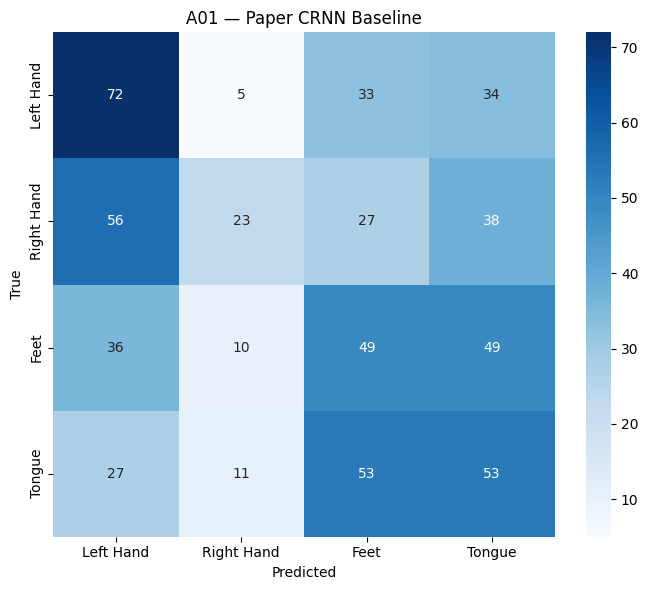

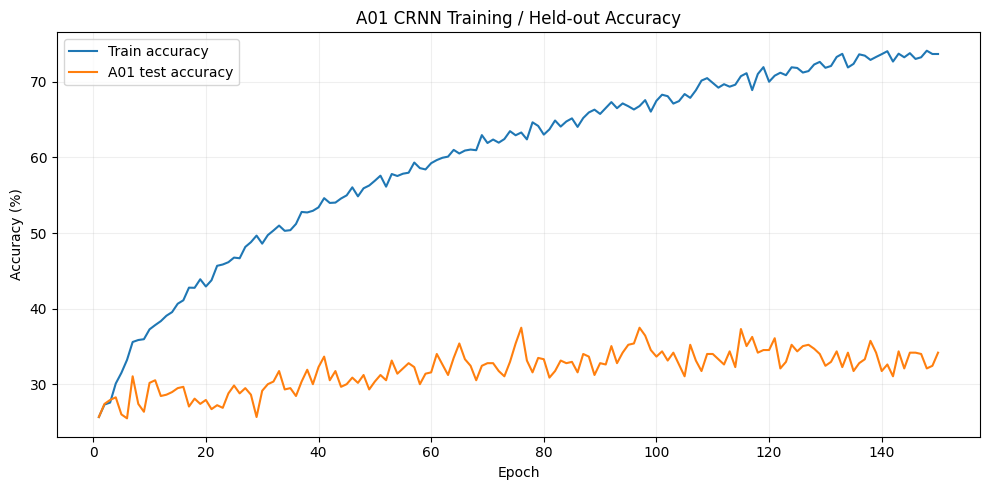


Stage-1 CRNN-only A01 = 34.20%


In [15]:
# ============================================================
# CELL — RUN STAGE-1 CRNN ON A01 STRICT LOSO
# ============================================================

assert Xln.shape == (4608, 22, 1000)
assert XTn.shape == (576, 22, 1000)

paper_crnn_result = train_paper_crnn(
    X_train=Xln,
    y_train=y_loso,
    X_test=XTn,
    y_test=y_test_loso,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    seed=42
)

print(
    f"\nStage-1 CRNN-only A01 = "
    f"{paper_crnn_result['accuracy'] * 100:.2f}%"
)


# STAGE 2 — CRNN-DF on Real BCI IV-2a

This notebook extends the validated real-data pipeline with the discriminative-feature stage.

Current validated baselines:
- A01T within-subject FBCSP+LDA ≈ 75%
- A01T → A01E FBCSP+LDA ≈ 75.7%
- A02–A09 → A01 FBCSP+LDA ≈ 42.9%
- A02–A09 → A01 mean-temporal CRNN ≈ 44.3%

This stage adds:
- 64-D mean-temporal CRNN embedding
- class-center initialization
- central-distance loss
- centroid shift
- λ = 0.1
- α = 0.02
- center update every 15 epochs
- batch size 32
- learning rate 1e-4
- 150 epochs

The held-out A01 subject is evaluated only after training. No FBGAN is enabled in this stage.


In [16]:
# ============================================================
# CELL — A01 BASELINE COMPARISON
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "FBCSP + LDA",
        "CRNN mean-temporal",
        "CRNN-DF"
    ],
    "A01 Accuracy (%)": [
        42.88,
        44.27,
        crnndf_result["accuracy"] * 100
    ]
})

display(
    comparison_df
)

print("""
Reference from Zhang et al.:
CRNN-DF A01 = 65.51%
CRNN-DF mean across A1-A9 = 63.52 ± 10.70%

Do not enable FBGAN until this CRNN-DF stage is validated.
""")


NameError: name 'crnndf_result' is not defined

# FINAL STAGE — Corrected CRNN-DF

This is the clean CRNN-DF implementation to run after the validated
real-data/LOSO/FBCSP pipeline.

Important correction:
- The paper describes a class center computed from the feature vectors
  of each category **within a batch**.
- The central-distance loss therefore uses current-mini-batch class centers.
- We do NOT use the previous frozen global-center loss for Lcen.
- Inter-class center distance is tracked diagnostically.
- The paper's centroid-shift idea is maintained as a separate center state.
- FBGAN is intentionally not included yet.

Paper settings used here:
- learning rate = 1e-4
- batch size = 32
- lambda_center = 0.1
- alpha = 0.02
- center update interval = 15
- hidden size = 64
- dropout = 0.5


In [17]:

# ============================================================
# CELL — CRNN-DF MODEL
# ============================================================

class CRNNDF(nn.Module):

    def __init__(
        self,
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=(n_channels, 45),
            stride=(1, 1),
            padding=(0, 0),
            bias=False
        )

        self.bn = nn.BatchNorm2d(32)

        self.conv_dropout = nn.Dropout(
            dropout
        )

        self.pool = nn.MaxPool2d(
            kernel_size=(1, 75),
            stride=(1, 10)
        )

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        self.feature_dropout = nn.Dropout(
            dropout
        )

        self.fc = nn.Linear(
            hidden_size,
            n_classes
        )

    def extract_features(self, x):

        # x: (B, 22, 1000)
        x = x.unsqueeze(1)

        # (B, 1, 22, 1000)
        x = self.conv(x)

        # (B, 32, 1, 956)
        x = self.bn(x)
        x = F.relu(x)
        x = self.conv_dropout(x)

        # (B, 32, 1, 89)
        x = self.pool(x)

        # (B, 32, 89)
        x = x.squeeze(2)

        # (B, 89, 32)
        x = x.transpose(1, 2)

        # (B, 89, 64)
        lstm_out, _ = self.lstm(x)

        # Mean temporal embedding; this was the better CRNN
        # baseline in the preceding experiment.
        features = lstm_out.mean(dim=1)

        # (B, 64)
        features = self.feature_dropout(features)

        return features

    def forward(self, x, return_features=False):

        features = self.extract_features(x)

        logits = self.fc(features)

        if return_features:
            return logits, features

        return logits


print("✅ CRNNDF defined.")


✅ CRNNDF defined.


In [18]:

# ============================================================
# CELL — BATCH CLASS CENTERS
# ============================================================

def compute_batch_class_centers(
    features,
    labels,
    n_classes=4
):
    centers = {}

    for class_id in range(n_classes):

        mask = (labels == class_id)

        if mask.any():

            class_features = features[mask]

            centers[class_id] = (
                class_features.mean(dim=0)
            )

    return centers


def batch_central_distance_loss(
    features,
    labels,
    n_classes=4
):
    """
    Current-mini-batch center loss.

    Lcen = mean distance from each sample feature to the
           center of its class within the current batch.
    """

    centers = compute_batch_class_centers(
        features,
        labels,
        n_classes=n_classes
    )

    if len(centers) == 0:
        return features.new_tensor(0.0), centers

    distances = []

    for class_id, center in centers.items():

        mask = (labels == class_id)

        class_features = features[mask]

        distances.append(
            torch.norm(
                class_features - center,
                p=2,
                dim=1
            )
        )

    all_distances = torch.cat(
        distances,
        dim=0
    )

    return (
        all_distances.mean(),
        centers
    )


def compute_inter_center_distance(
    centers
):
    """
    Diagnostic only:
    mean pairwise distance between batch class centers.
    """

    if centers is None or len(centers) < 2:
        return 0.0

    class_ids = sorted(centers.keys())

    values = []

    for i in range(len(class_ids)):

        for j in range(i + 1, len(class_ids)):

            c1 = centers[class_ids[i]]
            c2 = centers[class_ids[j]]

            values.append(
                torch.norm(
                    c1 - c2,
                    p=2
                ).detach().item()
            )

    return float(np.mean(values)) if values else 0.0


In [19]:

# ============================================================
# CELL — PAPER-INSPIRED CENTROID SHIFT
# ============================================================

@torch.no_grad()
def shift_centers(
    center_state,
    alpha=0.02
):
    """
    Paper-inspired center shift:
    move each class center slightly away from the global center.

    This center state is NOT used to compute the batch Lcen.
    """

    if center_state is None:
        return None

    if center_state.shape[0] < 2:
        return center_state

    global_center = center_state.mean(
        dim=0,
        keepdim=True
    )

    shifted = center_state.clone()

    for class_id in range(
        center_state.shape[0]
    ):

        direction = (
            center_state[class_id]
            - global_center[0]
        )

        norm = torch.norm(direction)

        if norm > 1e-12:

            direction = direction / norm

            shifted[class_id] = (
                center_state[class_id]
                + alpha * direction
            )

    return shifted


In [20]:

# ============================================================
# CELL — CORRECTED CRNN-DF TRAINING
# ============================================================

def train_corrected_crnndf(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    lambda_center=0.1,
    alpha=0.02,
    center_update_every=15,
    seed=42
):
    """
    Corrected CRNN-DF:

        Total Loss =
            CrossEntropy
            + lambda_center * BatchCenterDistance

    Batch center loss is computed from the CURRENT mini-batch.
    """

    reset_seed(seed)

    device = (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )

    print("Device:", device)

    model = CRNNDF(
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    # --------------------------------------------------------
    # TRAIN DATA
    # --------------------------------------------------------

    X_train_t = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_t = torch.tensor(
        y_train,
        dtype=torch.long
    )

    dataset = torch.utils.data.TensorDataset(
        X_train_t,
        y_train_t
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        drop_last=False
    )

    # --------------------------------------------------------
    # Epoch-level center state for diagnostic shifting
    # --------------------------------------------------------

    center_state = None

    history = []

    for epoch in range(
        1,
        epochs + 1
    ):

        model.train()

        total_loss_sum = 0.0
        ce_loss_sum = 0.0
        cen_loss_sum = 0.0
        correct = 0
        total = 0
        center_distance_values = []

        for xb, yb in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(
                set_to_none=True
            )

            logits, features = model(
                xb,
                return_features=True
            )

            ce_loss = criterion(
                logits,
                yb
            )

            cen_loss, batch_centers = (
                batch_central_distance_loss(
                    features,
                    yb,
                    n_classes=4
                )
            )

            loss = (
                ce_loss
                + lambda_center * cen_loss
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            n_batch = len(yb)

            total_loss_sum += (
                loss.item() * n_batch
            )

            ce_loss_sum += (
                ce_loss.item() * n_batch
            )

            cen_loss_sum += (
                cen_loss.item() * n_batch
            )

            correct += (
                (logits.argmax(dim=1) == yb)
                .sum()
                .item()
            )

            total += n_batch

            center_distance_values.append(
                compute_inter_center_distance(
                    batch_centers
                )
            )

        epoch_loss = total_loss_sum / total
        epoch_ce = ce_loss_sum / total
        epoch_cen = cen_loss_sum / total
        train_acc = correct / total

        mean_center_distance = (
            float(np.mean(center_distance_values))
            if center_distance_values
            else 0.0
        )

        # ----------------------------------------------------
        # Epoch-level center state
        # ----------------------------------------------------

        if (
            epoch == 1
            or epoch % center_update_every == 0
        ):

            model.eval()

            feature_parts = []
            label_parts = []

            with torch.no_grad():

                eval_loader = torch.utils.data.DataLoader(
                    dataset,
                    batch_size=64,
                    shuffle=False
                )

                for xb_all, yb_all in eval_loader:

                    xb_all = xb_all.to(device)

                    feats_all = (
                        model.extract_features(
                            xb_all
                        )
                    )

                    feature_parts.append(
                        feats_all.cpu()
                    )

                    label_parts.append(
                        yb_all
                    )

            epoch_features = torch.cat(
                feature_parts,
                dim=0
            )

            epoch_labels = torch.cat(
                label_parts,
                dim=0
            )

            epoch_centers = []

            for class_id in range(4):

                class_feats = (
                    epoch_features[
                        epoch_labels == class_id
                    ]
                )

                epoch_centers.append(
                    class_feats.mean(dim=0)
                )

            center_state = torch.stack(
                epoch_centers,
                dim=0
            ).to(device)

            center_state = shift_centers(
                center_state,
                alpha=alpha
            )

        history.append({
            "epoch": epoch,
            "loss": epoch_loss,
            "ce": epoch_ce,
            "center_loss": epoch_cen,
            "inter_center_distance": mean_center_distance,
            "train_accuracy": train_acc
        })

        if (
            epoch == 1
            or epoch % 10 == 0
            or epoch == epochs
        ):

            print(
                f"Epoch {epoch:03d} | "
                f"loss={epoch_loss:.4f} | "
                f"CE={epoch_ce:.4f} | "
                f"CEN={epoch_cen:.4f} | "
                f"SEP={mean_center_distance:.4f} | "
                f"train={train_acc*100:.2f}%"
            )

    # ========================================================
    # FINAL HELD-OUT A01 EVALUATION
    # ========================================================

    model.eval()

    X_test_t = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    prediction_parts = []
    feature_parts = []

    with torch.no_grad():

        for start in range(
            0,
            len(X_test_t),
            batch_size
        ):

            xb = X_test_t[
                start:start + batch_size
            ].to(device)

            logits, features = model(
                xb,
                return_features=True
            )

            prediction_parts.append(
                logits.argmax(
                    dim=1
                ).cpu().numpy()
            )

            feature_parts.append(
                features.cpu().numpy()
            )

    y_pred = np.concatenate(
        prediction_parts
    )

    test_features = np.concatenate(
        feature_parts,
        axis=0
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=np.arange(4)
    )

    print("\n" + "=" * 72)
    print("A01 CORRECTED CRNN-DF")
    print("=" * 72)
    print(
        f"Accuracy      : {accuracy*100:.2f}%"
    )
    print(
        f"Balanced Acc  : {balanced_acc*100:.2f}%"
    )
    print(
        f"Kappa         : {kappa:.4f}"
    )
    print("=" * 72)

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    plt.figure(
        figsize=(7, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(
        "A01 — Corrected CRNN-DF"
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history_df = pd.DataFrame(history)

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(10, 15)
    )

    axes[0].plot(
        history_df["epoch"],
        history_df["loss"]
    )
    axes[0].set_title("Total Loss")
    axes[0].set_ylabel("Loss")

    axes[1].plot(
        history_df["epoch"],
        history_df["ce"]
    )
    axes[1].set_title("Cross Entropy")
    axes[1].set_ylabel("CE")

    axes[2].plot(
        history_df["epoch"],
        history_df["center_loss"]
    )
    axes[2].set_title(
        "Batch Center Distance Loss"
    )
    axes[2].set_ylabel("CEN")

    axes[3].plot(
        history_df["epoch"],
        history_df["inter_center_distance"]
    )
    axes[3].set_title(
        "Mean Inter-Class Center Distance"
    )
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("Distance")

    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "center_state": center_state,
        "history": history_df,
        "predictions": y_pred,
        "test_features": test_features,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "kappa": kappa,
        "confusion_matrix": cm,
        "device": device
    }


Device: mps
Epoch 001 | loss=1.4225 | CE=1.3893 | CEN=0.3320 | SEP=0.1836 | train=26.30%
Epoch 010 | loss=1.3411 | CE=1.2894 | CEN=0.5170 | SEP=0.4499 | train=39.97%
Epoch 020 | loss=1.1851 | CE=1.0836 | CEN=1.0144 | SEP=0.9917 | train=52.69%
Epoch 030 | loss=1.0950 | CE=0.9838 | CEN=1.1122 | SEP=1.1505 | train=58.72%
Epoch 040 | loss=1.0152 | CE=0.9018 | CEN=1.1341 | SEP=1.2005 | train=63.35%
Epoch 050 | loss=0.9770 | CE=0.8650 | CEN=1.1200 | SEP=1.2240 | train=63.80%
Epoch 060 | loss=0.9168 | CE=0.8049 | CEN=1.1188 | SEP=1.2584 | train=68.25%
Epoch 070 | loss=0.8603 | CE=0.7497 | CEN=1.1052 | SEP=1.2802 | train=70.12%
Epoch 080 | loss=0.8221 | CE=0.7130 | CEN=1.0911 | SEP=1.2988 | train=71.59%
Epoch 090 | loss=0.7783 | CE=0.6703 | CEN=1.0796 | SEP=1.3078 | train=74.41%
Epoch 100 | loss=0.7328 | CE=0.6242 | CEN=1.0857 | SEP=1.3348 | train=76.19%
Epoch 110 | loss=0.7064 | CE=0.6014 | CEN=1.0495 | SEP=1.3109 | train=76.95%
Epoch 120 | loss=0.6490 | CE=0.5455 | CEN=1.0354 | SEP=1.3462 | 

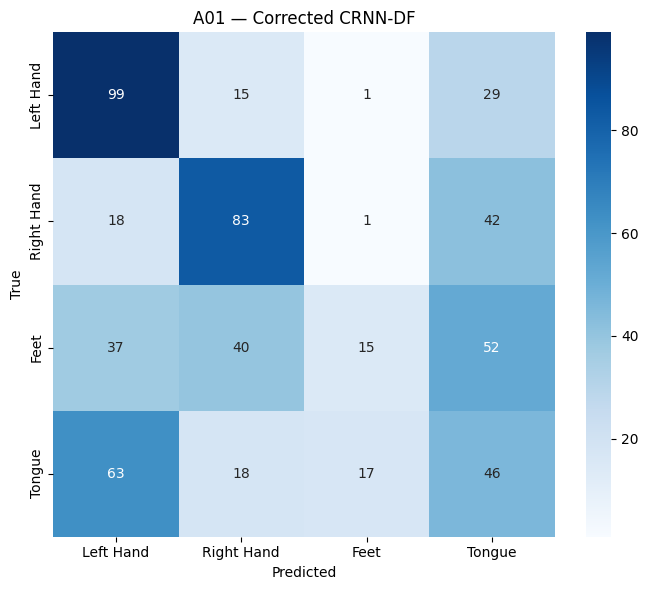

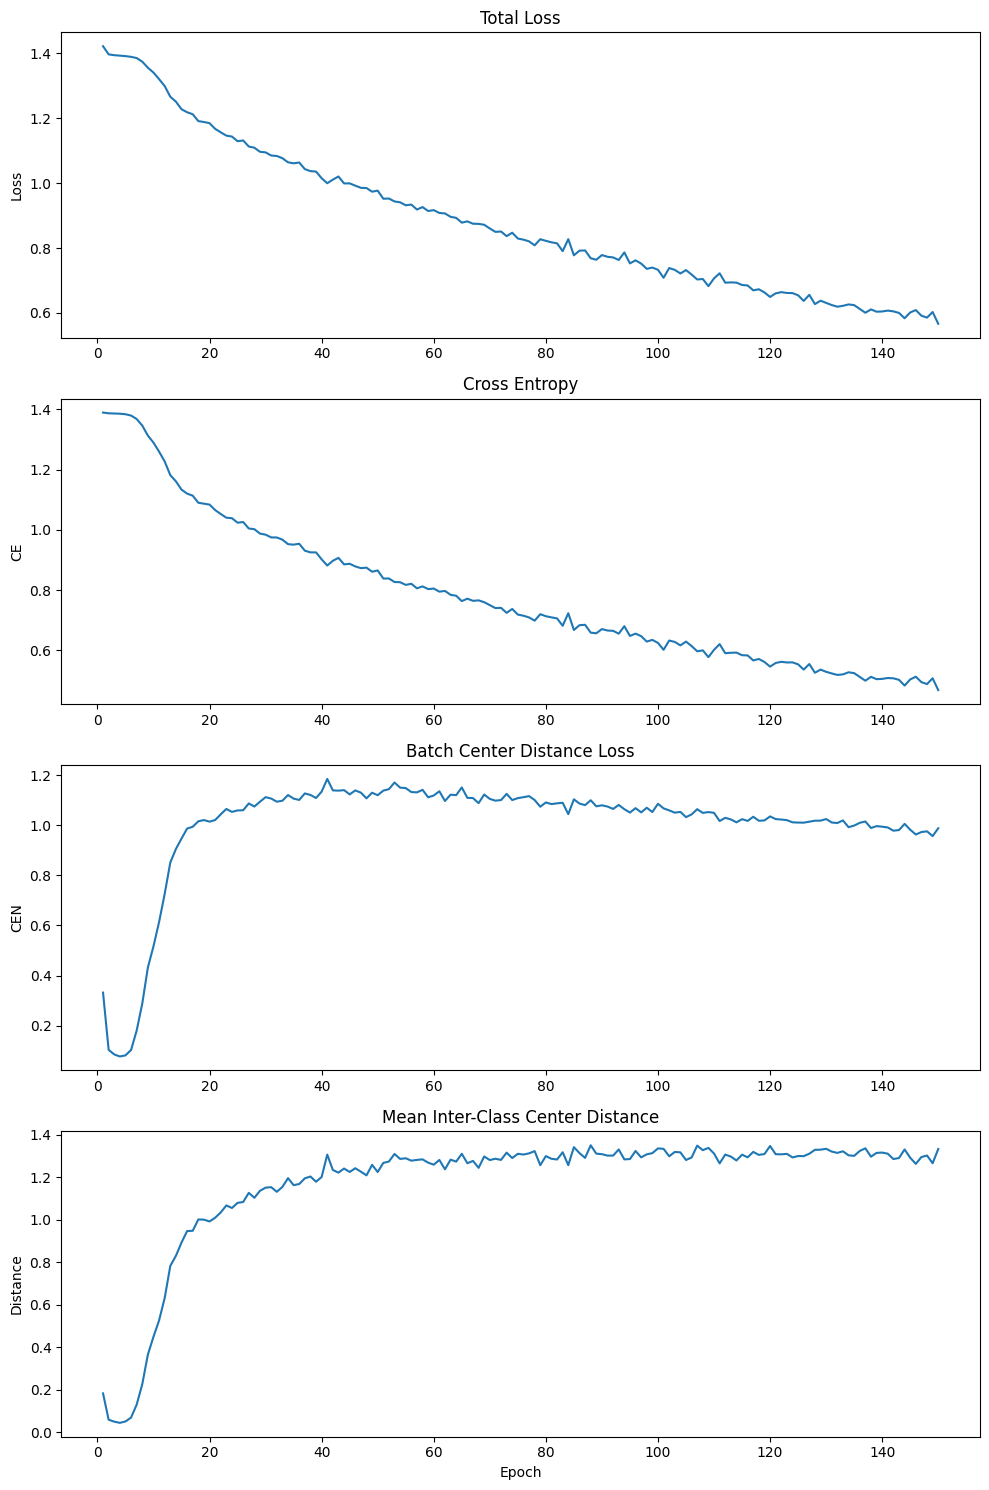


Corrected CRNN-DF A01 = 42.19%


In [21]:

# ============================================================
# CELL — RUN CORRECTED CRNN-DF ON A01
# ============================================================

assert Xln.shape == (
    4608,
    22,
    1000
)

assert XTn.shape == (
    576,
    22,
    1000
)

assert y_loso.shape == (
    4608,
)

assert y_test_loso.shape == (
    576,
)

corrected_crnndf_result = train_corrected_crnndf(
    X_train=Xln,
    y_train=y_loso,

    X_test=XTn,
    y_test=y_test_loso,

    epochs=150,
    batch_size=32,
    lr=1e-4,

    lambda_center=0.1,
    alpha=0.02,
    center_update_every=15,

    seed=42
)

print(
    "\nCorrected CRNN-DF A01 = "
    f"{corrected_crnndf_result['accuracy'] * 100:.2f}%"
)


# STAGE 3 — Full 9-subject LOSO diagnostic

This stage evaluates the current mean-temporal CRNN and corrected
batch-center CRNN-DF across **all nine BCI IV-2a subjects**.

For every fold:
- one subject is held out;
- the remaining eight subjects form the training set;
- normalization uses training subjects only;
- no held-out test accuracy is used for model selection;
- the held-out subject is evaluated only after training.

The paper reports the LOSO setup as eight subjects for training and one
for evaluation, using 4,608 training trials and 576 test trials. fileciteturn4file4L337-L353

Reference:
- Paper CRNN-DF mean: 63.52 ± 10.70%
- Paper + 3,000 FBGAN samples: 72.82 ± 10.44%


In [22]:

# ============================================================
# CELL — VERIFY ALL SUBJECTS
# ============================================================

assert "ALL_SUBJECTS" in globals(), (
    "ALL_SUBJECTS is missing. Run the real-data loading cells first."
)

SUBJECT_IDS = [f"A{i:02d}" for i in range(1, 10)]

for sid in SUBJECT_IDS:
    assert sid in ALL_SUBJECTS
    assert ALL_SUBJECTS[sid]["X"].shape == (576, 22, 1000)
    assert ALL_SUBJECTS[sid]["y"].shape == (576,)

print("✅ All 9 subjects loaded.")


✅ All 9 subjects loaded.


In [23]:

# ============================================================
# CELL — LOSO FOLD PREPARATION
# ============================================================

def make_loso_fold(test_subject):

    train_subjects = [
        sid for sid in SUBJECT_IDS
        if sid != test_subject
    ]

    X_train = np.concatenate(
        [ALL_SUBJECTS[sid]["X"] for sid in train_subjects],
        axis=0
    )

    y_train = np.concatenate(
        [ALL_SUBJECTS[sid]["y"] for sid in train_subjects],
        axis=0
    )

    X_test = ALL_SUBJECTS[test_subject]["X"]
    y_test = ALL_SUBJECTS[test_subject]["y"]

    mu, sd = fit_norm(X_train)

    X_train = norm(
        X_train,
        mu,
        sd
    )

    X_test = norm(
        X_test,
        mu,
        sd
    )

    return {
        "train_subjects": train_subjects,
        "test_subject": test_subject,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test
    }


for sid in SUBJECT_IDS:
    fold = make_loso_fold(sid)

    assert fold["X_train"].shape == (4608, 22, 1000)
    assert fold["X_test"].shape == (576, 22, 1000)

print("✅ All LOSO folds validated.")


✅ All LOSO folds validated.


In [24]:

# ============================================================
# CELL — 9-FOLD CRNN TRAINER
# ============================================================

def run_crnn_fold(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    seed=42
):

    reset_seed(seed)

    device = (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )

    model = PaperCRNN(
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    Xtr = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    ytr = torch.tensor(
        y_train,
        dtype=torch.long
    )

    Xte = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    dataset = torch.utils.data.TensorDataset(
        Xtr,
        ytr
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    for _ in range(epochs):

        model.train()

        for xb, yb in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0
            )

            optimizer.step()

    model.eval()

    preds = []

    with torch.no_grad():

        for start in range(
            0,
            len(Xte),
            batch_size
        ):

            xb = Xte[
                start:start + batch_size
            ].to(device)

            preds.append(
                model(xb)
                .argmax(1)
                .cpu()
                .numpy()
            )

    y_pred = np.concatenate(
        preds
    )

    return {
        "accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),
        "kappa": cohen_kappa_score(
            y_test,
            y_pred
        )
    }


In [25]:

# ============================================================
# CELL — 9-FOLD CORRECTED CRNN-DF TRAINER
# ============================================================

def run_crnndf_fold(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    lambda_center=0.1,
    alpha=0.02,
    center_update_every=15,
    seed=42
):

    reset_seed(seed)

    device = (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )

    model = CRNNDF(
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    Xtr = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    ytr = torch.tensor(
        y_train,
        dtype=torch.long
    )

    Xte = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    dataset = torch.utils.data.TensorDataset(
        Xtr,
        ytr
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    center_state = None

    for epoch in range(1, epochs + 1):

        model.train()

        for xb, yb in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits, features = model(
                xb,
                return_features=True
            )

            ce_loss = criterion(
                logits,
                yb
            )

            cen_loss, batch_centers = (
                batch_central_distance_loss(
                    features,
                    yb,
                    n_classes=4
                )
            )

            loss = (
                ce_loss
                + lambda_center * cen_loss
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0
            )

            optimizer.step()

        if epoch == 1 or epoch % center_update_every == 0:

            # Diagnostic center-state update only.
            model.eval()

            feature_chunks = []
            label_chunks = []

            with torch.no_grad():

                eval_loader = torch.utils.data.DataLoader(
                    dataset,
                    batch_size=64,
                    shuffle=False
                )

                for xb_all, yb_all in eval_loader:

                    xb_all = xb_all.to(device)

                    feature_chunks.append(
                        model.extract_features(
                            xb_all
                        ).cpu()
                    )

                    label_chunks.append(
                        yb_all
                    )

            all_features = torch.cat(
                feature_chunks
            )

            all_labels = torch.cat(
                label_chunks
            )

            centers = []

            for class_id in range(4):

                centers.append(
                    all_features[
                        all_labels == class_id
                    ].mean(dim=0)
                )

            center_state = torch.stack(
                centers
            ).to(device)

            center_state = shift_centers(
                center_state,
                alpha=alpha
            )

    model.eval()

    preds = []

    with torch.no_grad():

        for start in range(
            0,
            len(Xte),
            batch_size
        ):

            xb = Xte[
                start:start + batch_size
            ].to(device)

            logits = model(xb)

            preds.append(
                logits.argmax(1)
                .cpu()
                .numpy()
            )

    y_pred = np.concatenate(
        preds
    )

    return {
        "accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),
        "kappa": cohen_kappa_score(
            y_test,
            y_pred
        )
    }


# STAGE 4 — Recommended CRNN-DF stability + center-update experiment

This is the recommended next experiment before FBGAN.

Goals:
1. Compare CRNN and corrected CRNN-DF with the **same seed for each fold**.
2. Repeat the full 9-subject LOSO experiment across **3 seeds**.
3. Keep the objective as:
       Loss = CrossEntropy + lambda * Lcen
   with lambda = 0.1.
4. Keep batch-wise class centers for Lcen, matching the paper's description.
5. Track the paper-inspired center-shift state separately.
6. Report:
   - per-subject accuracy,
   - 9-subject mean ± sample std,
   - mean improvement CRNN-DF − CRNN,
   - cross-seed stability.

This is a stability/reproducibility experiment. It is NOT the final FBGAN experiment.

The paper describes LOSO as 8 subjects for training and 1 held-out subject for evaluation, with 4,608 training trials and 576 test trials. It also states that a center vector is computed for each category in a batch for the central-distance loss, followed by the discriminative center expansion and joint classification + central-distance optimization. fileciteturn4file4L337-L353 fileciteturn5file0L5-L13


In [26]:

# ============================================================
# CELL — EXPERIMENT CONFIGURATION
# ============================================================

SEEDS = [42, 43, 44]

STABILITY_EPOCHS = 150
STABILITY_BATCH_SIZE = 32
STABILITY_LR = 1e-4

CENTER_LAMBDA = 0.1
CENTER_ALPHA = 0.02
CENTER_UPDATE_EVERY = 15

print("Seeds:", SEEDS)
print("Epochs per fold/model:", STABILITY_EPOCHS)
print("Batch size:", STABILITY_BATCH_SIZE)
print("Learning rate:", STABILITY_LR)
print("Center lambda:", CENTER_LAMBDA)
print("Center alpha:", CENTER_ALPHA)
print("Center update interval:", CENTER_UPDATE_EVERY)


Seeds: [42, 43, 44]
Epochs per fold/model: 150
Batch size: 32
Learning rate: 0.0001
Center lambda: 0.1
Center alpha: 0.02
Center update interval: 15


In [27]:

# ============================================================
# CELL — SAME-SEED CRNN FOLD TRAINER
# ============================================================

def run_crnn_fold_stable(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    seed=42
):
    reset_seed(seed)

    device = (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )

    model = PaperCRNN(
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.long)
    Xte = torch.tensor(X_test, dtype=torch.float32)

    dataset = torch.utils.data.TensorDataset(Xtr, ytr)

    g = torch.Generator()
    g.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        drop_last=False
    )

    for epoch in range(1, epochs + 1):

        model.train()

        for xb, yb in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

    model.eval()

    preds = []

    with torch.no_grad():
        for start in range(0, len(Xte), batch_size):

            xb = Xte[start:start + batch_size].to(device)

            preds.append(
                model(xb).argmax(dim=1).cpu().numpy()
            )

    y_pred = np.concatenate(preds)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "kappa": cohen_kappa_score(y_test, y_pred)
    }


In [28]:

# ============================================================
# CELL — SAME-SEED CRNN-DF FOLD TRAINER
# ============================================================

def run_crnndf_fold_stable(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    lambda_center=0.1,
    alpha=0.02,
    center_update_every=15,
    seed=42
):
    """
    Stable CRNN-DF fold.

    Lcen is computed from CURRENT MINI-BATCH class centers.
    The center-state update is kept separate from Lcen.
    """

    reset_seed(seed)

    device = (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )

    model = CRNNDF(
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.long)
    Xte = torch.tensor(X_test, dtype=torch.float32)

    dataset = torch.utils.data.TensorDataset(Xtr, ytr)

    g = torch.Generator()
    g.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        drop_last=False
    )

    center_state = None
    epoch_center_distance = []

    for epoch in range(1, epochs + 1):

        model.train()

        fold_center_distances = []

        for xb, yb in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits, features = model(
                xb,
                return_features=True
            )

            ce_loss = criterion(
                logits,
                yb
            )

            cen_loss, batch_centers = (
                batch_central_distance_loss(
                    features,
                    yb,
                    n_classes=4
                )
            )

            loss = (
                ce_loss
                + lambda_center * cen_loss
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            fold_center_distances.append(
                compute_inter_center_distance(
                    batch_centers
                )
            )

        epoch_center_distance.append(
            float(np.mean(fold_center_distances))
        )

        # Update diagnostic epoch center state.
        # This does not replace the batch centers used in Lcen.
        if epoch == 1 or epoch % center_update_every == 0:

            model.eval()

            feature_parts = []
            label_parts = []

            with torch.no_grad():

                eval_loader = torch.utils.data.DataLoader(
                    dataset,
                    batch_size=64,
                    shuffle=False
                )

                for xb_all, yb_all in eval_loader:

                    xb_all = xb_all.to(device)

                    feature_parts.append(
                        model.extract_features(xb_all).cpu()
                    )

                    label_parts.append(yb_all)

            all_features = torch.cat(feature_parts, dim=0)
            all_labels = torch.cat(label_parts, dim=0)

            centers = []

            for class_id in range(4):

                class_features = all_features[
                    all_labels == class_id
                ]

                centers.append(
                    class_features.mean(dim=0)
                )

            center_state = torch.stack(
                centers,
                dim=0
            ).to(device)

            center_state = shift_centers(
                center_state,
                alpha=alpha
            )

    # Final held-out evaluation only.
    model.eval()

    preds = []

    with torch.no_grad():

        for start in range(0, len(Xte), batch_size):

            xb = Xte[start:start + batch_size].to(device)

            preds.append(
                model(xb).argmax(dim=1).cpu().numpy()
            )

    y_pred = np.concatenate(preds)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "kappa": cohen_kappa_score(y_test, y_pred),
        "mean_inter_center_distance": float(
            np.mean(epoch_center_distance)
        )
    }


In [29]:

# ============================================================
# CELL — RUN 3-SEED × 9-FOLD STABILITY EXPERIMENT
# ============================================================

stability_rows = []

for seed in SEEDS:

    print("\n" + "=" * 80)
    print(f"GLOBAL SEED = {seed}")
    print("=" * 80)

    for fold_number, test_subject in enumerate(
        SUBJECT_IDS,
        start=1
    ):

        # The SAME seed is used for CRNN and CRNN-DF in the fold.
        fold_seed = seed + fold_number

        print(
            f"\nFold {fold_number}/9 | "
            f"Holdout {test_subject} | "
            f"Seed {fold_seed}"
        )

        fold = make_loso_fold(
            test_subject
        )

        crnn_metrics = run_crnn_fold_stable(
            X_train=fold["X_train"],
            y_train=fold["y_train"],
            X_test=fold["X_test"],
            y_test=fold["y_test"],
            epochs=STABILITY_EPOCHS,
            batch_size=STABILITY_BATCH_SIZE,
            lr=STABILITY_LR,
            seed=fold_seed
        )

        crnndf_metrics = run_crnndf_fold_stable(
            X_train=fold["X_train"],
            y_train=fold["y_train"],
            X_test=fold["X_test"],
            y_test=fold["y_test"],
            epochs=STABILITY_EPOCHS,
            batch_size=STABILITY_BATCH_SIZE,
            lr=STABILITY_LR,
            lambda_center=CENTER_LAMBDA,
            alpha=CENTER_ALPHA,
            center_update_every=CENTER_UPDATE_EVERY,
            seed=fold_seed
        )

        print(
            f"CRNN={crnn_metrics['accuracy']*100:.2f}% | "
            f"CRNN-DF={crnndf_metrics['accuracy']*100:.2f}%"
        )

        stability_rows.append({
            "seed": seed,
            "fold_seed": fold_seed,
            "subject": test_subject,

            "CRNN": crnn_metrics["accuracy"] * 100,
            "CRNN_balanced":
                crnn_metrics["balanced_accuracy"] * 100,
            "CRNN_kappa":
                crnn_metrics["kappa"],

            "CRNN_DF":
                crnndf_metrics["accuracy"] * 100,
            "CRNN_DF_balanced":
                crnndf_metrics["balanced_accuracy"] * 100,
            "CRNN_DF_kappa":
                crnndf_metrics["kappa"],

            "DF_minus_CRNN":
                (
                    crnndf_metrics["accuracy"]
                    - crnn_metrics["accuracy"]
                ) * 100,

            "mean_inter_center_distance":
                crnndf_metrics[
                    "mean_inter_center_distance"
                ]
        })

stability_df = pd.DataFrame(
    stability_rows
)

display(
    stability_df.round(3)
)

stability_df.to_csv(
    "BCI2A_CRNNDF_3SEED_9FOLD_STABILITY.csv",
    index=False
)

print(
    "\nSaved: BCI2A_CRNNDF_3SEED_9FOLD_STABILITY.csv"
)



GLOBAL SEED = 42

Fold 1/9 | Holdout A01 | Seed 43
CRNN=43.75% | CRNN-DF=44.97%

Fold 2/9 | Holdout A02 | Seed 44
CRNN=29.34% | CRNN-DF=28.82%

Fold 3/9 | Holdout A03 | Seed 45
CRNN=46.88% | CRNN-DF=52.60%

Fold 4/9 | Holdout A04 | Seed 46
CRNN=33.85% | CRNN-DF=32.99%

Fold 5/9 | Holdout A05 | Seed 47
CRNN=24.65% | CRNN-DF=31.08%

Fold 6/9 | Holdout A06 | Seed 48
CRNN=35.42% | CRNN-DF=36.98%

Fold 7/9 | Holdout A07 | Seed 49
CRNN=24.13% | CRNN-DF=32.81%

Fold 8/9 | Holdout A08 | Seed 50
CRNN=52.78% | CRNN-DF=57.64%

Fold 9/9 | Holdout A09 | Seed 51
CRNN=46.35% | CRNN-DF=54.17%

GLOBAL SEED = 43

Fold 1/9 | Holdout A01 | Seed 44
CRNN=35.42% | CRNN-DF=49.48%

Fold 2/9 | Holdout A02 | Seed 45
CRNN=26.56% | CRNN-DF=31.94%

Fold 3/9 | Holdout A03 | Seed 46
CRNN=35.24% | CRNN-DF=53.65%

Fold 4/9 | Holdout A04 | Seed 47
CRNN=28.47% | CRNN-DF=30.56%

Fold 5/9 | Holdout A05 | Seed 48
CRNN=27.26% | CRNN-DF=26.04%

Fold 6/9 | Holdout A06 | Seed 49
CRNN=40.97% | CRNN-DF=39.93%

Fold 7/9 | Holdout

,seed,fold_seed,subject,CRNN,CRNN_balanced,CRNN_kappa,CRNN_DF,CRNN_DF_balanced,CRNN_DF_kappa,DF_minus_CRNN,mean_inter_center_distance
0,42,43,A01,43.750,43.750,0.250,44.965,44.965,0.266,1.215,1.155
1,42,44,A02,29.340,29.340,0.058,28.819,28.819,0.051,-0.521,1.414
2,42,45,A03,46.875,46.875,0.292,52.604,52.604,0.368,5.729,1.130
3,42,46,A04,33.854,33.854,0.118,32.986,32.986,0.106,-0.868,1.329
4,42,47,A05,24.653,24.653,-0.005,31.076,31.076,0.081,6.424,1.414
5,42,48,A06,35.417,35.417,0.139,36.979,36.979,0.160,1.562,1.332
6,42,49,A07,24.132,24.132,-0.012,32.812,32.812,0.104,8.681,1.263
7,42,50,A08,52.778,52.778,0.370,57.639,57.639,0.435,4.861,1.172
8,42,51,A09,46.354,46.354,0.285,54.167,54.167,0.389,7.812,1.201
9,43,44,A01,35.417,35.417,0.139,49.479,49.479,0.326,14.062,1.193



Saved: BCI2A_CRNNDF_3SEED_9FOLD_STABILITY.csv


In [30]:

# ============================================================
# CELL — PER-SEED SUMMARY
# ============================================================

seed_summary = (
    stability_df
    .groupby("seed")
    .agg(
        CRNN_mean=("CRNN", "mean"),
        CRNN_std=("CRNN", "std"),
        CRNN_DF_mean=("CRNN_DF", "mean"),
        CRNN_DF_std=("CRNN_DF", "std"),
        improvement_mean=("DF_minus_CRNN", "mean"),
        improvement_std=("DF_minus_CRNN", "std")
    )
    .reset_index()
)

display(
    seed_summary.round(3)
)

print("\nPer-seed summary:")
print(seed_summary.round(3).to_string(index=False))


,seed,CRNN_mean,CRNN_std,CRNN_DF_mean,CRNN_DF_std,improvement_mean,improvement_std
0,42,37.461,10.409,41.339,11.146,3.877,3.601
1,43,35.571,10.327,41.281,11.737,5.710,6.725
2,44,36.208,10.660,44.136,12.581,7.928,6.101



Per-seed summary:
 seed  CRNN_mean  CRNN_std  CRNN_DF_mean  CRNN_DF_std  improvement_mean  improvement_std
   42     37.461    10.409        41.339       11.146             3.877            3.601
   43     35.571    10.327        41.281       11.737             5.710            6.725
   44     36.208    10.660        44.136       12.581             7.928            6.101


In [31]:

# ============================================================
# CELL — OVERALL STABILITY SUMMARY
# ============================================================

overall_crnn_mean = (
    stability_df["CRNN"].mean()
)

overall_crnn_std = (
    stability_df
    .groupby("seed")["CRNN"]
    .mean()
    .std(ddof=1)
)

overall_df_mean = (
    stability_df["CRNN_DF"].mean()
)

overall_df_std = (
    stability_df
    .groupby("seed")["CRNN_DF"]
    .mean()
    .std(ddof=1)
)

fold_level_df_std = (
    stability_df["CRNN_DF"].std(ddof=1)
)

mean_gain = (
    stability_df["DF_minus_CRNN"].mean()
)

gain_std = (
    stability_df["DF_minus_CRNN"].std(ddof=1)
)

print("=" * 80)
print("3-SEED / 9-FOLD CRNN-DF STABILITY")
print("=" * 80)

print(
    f"CRNN overall fold mean            : "
    f"{overall_crnn_mean:.2f}%"
)

print(
    f"CRNN mean variation across seeds  : "
    f"{overall_crnn_std:.2f}%"
)

print(
    f"CRNN-DF overall fold mean         : "
    f"{overall_df_mean:.2f}%"
)

print(
    f"CRNN-DF mean variation by seed    : "
    f"{overall_df_std:.2f}%"
)

print(
    f"CRNN-DF fold-level sample std     : "
    f"{fold_level_df_std:.2f}%"
)

print(
    f"Mean DF - CRNN improvement        : "
    f"{mean_gain:.2f} ± {gain_std:.2f} percentage points"
)

print("=" * 80)

print(
    "\nPublished reference:"
)

print(
    "CRNN-DF = 63.52 ± 10.70%"
)

print(
    "CRNN-DF + 3000 FBGAN = 72.82 ± 10.44%"
)


3-SEED / 9-FOLD CRNN-DF STABILITY
CRNN overall fold mean            : 36.41%
CRNN mean variation across seeds  : 0.96%
CRNN-DF overall fold mean         : 42.25%
CRNN-DF mean variation by seed    : 1.63%
CRNN-DF fold-level sample std     : 11.45%
Mean DF - CRNN improvement        : 5.84 ± 5.68 percentage points

Published reference:
CRNN-DF = 63.52 ± 10.70%
CRNN-DF + 3000 FBGAN = 72.82 ± 10.44%


In [32]:

# ============================================================
# CELL — SUBJECT-LEVEL CROSS-SEED STABILITY
# ============================================================

subject_summary = (
    stability_df
    .groupby("subject")
    .agg(
        CRNN_mean=("CRNN", "mean"),
        CRNN_std=("CRNN", "std"),
        CRNN_DF_mean=("CRNN_DF", "mean"),
        CRNN_DF_std=("CRNN_DF", "std"),
        DF_gain_mean=("DF_minus_CRNN", "mean"),
        DF_gain_std=("DF_minus_CRNN", "std")
    )
    .reset_index()
)

display(
    subject_summary.round(3)
)

print(
    "\nSubjects where CRNN-DF has negative mean gain:"
)

negative = subject_summary[
    subject_summary["DF_gain_mean"] < 0
]

display(
    negative.round(3)
)


,subject,CRNN_mean,CRNN_std,CRNN_DF_mean,CRNN_DF_std,DF_gain_mean,DF_gain_std
0,A01,42.766,6.910,49.942,5.224,7.176,6.473
1,A02,27.257,1.837,28.877,3.039,1.620,3.268
2,A03,40.451,5.910,53.183,0.530,12.731,6.441
3,A04,30.671,2.823,34.722,5.254,4.051,6.144
4,A05,26.100,1.326,28.877,2.577,2.778,3.831
5,A06,37.153,3.312,38.021,1.656,0.868,1.674
6,A07,24.711,0.856,35.012,2.953,10.301,3.268
7,A08,46.238,5.680,54.109,7.508,7.870,7.743
8,A09,52.373,5.494,57.523,3.222,5.150,2.331



Subjects where CRNN-DF has negative mean gain:


,subject,CRNN_mean,CRNN_std,CRNN_DF_mean,CRNN_DF_std,DF_gain_mean,DF_gain_std


In [33]:

# ============================================================
# CELL — DECISION GATE
# ============================================================

print("=" * 80)
print("NEXT-STEP DECISION GATE")
print("=" * 80)

if overall_df_mean >= 60:
    print(
        "CRNN-DF is approaching the published baseline. "
        "Proceed to paper-faithful FBGAN."
    )

elif overall_df_mean > overall_crnn_mean:
    print(
        "CRNN-DF is consistently better than CRNN but still "
        "below the published baseline. Investigate the remaining "
        "CRNN-DF architecture/center-update discrepancy before FBGAN."
    )

else:
    print(
        "CRNN-DF is not reliably better than CRNN. Do not start "
        "FBGAN. Revisit the CRNN-DF feature representation."
    )

print("=" * 80)


NEXT-STEP DECISION GATE
CRNN-DF is consistently better than CRNN but still below the published baseline. Investigate the remaining CRNN-DF architecture/center-update discrepancy before FBGAN.
